## CitySeer: Métricas Configuracionais do Espaço Urbano

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [1]:
from __future__ import annotations

# ============================================================================
# Standard library
# ============================================================================
import joblib
import os
import pathlib
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple, Type

# ============================================================================
# Third-party libraries
# ============================================================================
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels
import xgboost as xgb
from matplotlib_scalebar import scalebar
from scipy.stats import hmean
from shapely.geometry import Polygon
from shapely.ops import unary_union
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler, minmax_scale
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant, maybe_unwrap_results


sns.set_theme(style="dark")
sns.set_context("paper")

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

In [3]:
MAIN_DATA = Path(os.environ.get('DB_FOLDER'))

FOLDER = os.environ.get('OUT_FOLDER')

DATABASE = Path(FOLDER)

OUT_DIR = Path(FOLDER) / 'B/cityseer'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
OUT_PARQUET    = (
    OUT_DIR
    / f"accessibilities.parquet"
    )

access = pd.read_parquet(
    OUT_PARQUET
)

In [5]:
OUT_PARQUET    = (
    OUT_DIR
    / f"nodes.parquet"
    )

nodes = gpd.read_parquet(
    OUT_PARQUET
)

In [6]:
OUT_PARQUET    = (
    OUT_DIR
    / f"centralities.parquet"
    )
centralities = pd.read_parquet(
    OUT_PARQUET
)

In [7]:
slicers = [
    ('income', 'public', 'shortest', 1500),
    ('income', 'private', 'shortest', 1500),
    ('income', 'walk', 'shortest', 1500),
    ('households', 'public', 'shortest', 1500),
    ('households', 'private', 'shortest', 1500),
    ('households', 'walk', 'shortest', 1500),
]

db = []
for slice in slicers:
    df = centralities.xs(slice, level=('weight', 'mode', 'path', 'radius'))
    df = df[['betweenness_beta', 'harmonic', 'beta']]
    df.columns = [f"{slice[0]}_{col}_{slice[1]}" for col in df.columns]

    db.append(df.copy())

db = pd.concat(db, axis=1)

retail = access.xs(('yes', 500), level=('weight', 'radius')).filter(like='access')
hill = access.xs(('yes', 500), level=('weight', 'radius')).filter(like='hill')

db = pd.concat([
    retail,
    hill,
    db,
        
], axis='columns')

db = nodes[['x', 'y', 'primal_edge']].merge(
    db,
    left_index=True,
    right_index=True,
)


In [8]:
db_folder = os.environ.get('DB_FOLDER')
db_folder = pathlib.Path(db_folder) / 'beaga'

inpath = db_folder / 'zoning/ZONAS_Lei_7166-96.zip'
old_zoning = gpd.read_file(inpath)

old_zoning = old_zoning.loc[~old_zoning.SIGLA_ZONE.isin([
    'ZEPIL', 'ZEJAT', 'ZEIS1', 'ZEIS2', 'ZEIS3',
    'ZPAM', 'ZP1', 'ZP2', 'ZP3', 'ZE',
    ])]

db = db.sjoin_nearest(
    old_zoning[['geometry']],
    max_distance=25,
).drop(columns=['index_right'])

db = db.loc[~db.index.duplicated()]

In [9]:
inpath =  DATABASE / 'A/entorno.gpkg'
surroundings = gpd.read_file(inpath).to_crs(31983)

db = db.sjoin(surroundings, how="left", predicate="intersects").drop(columns=['index_right'])
db = db.loc[~db.index.duplicated()].drop(columns='id_setor_censitario')

In [10]:
inpath =  DATABASE / 'A/crime_by_borough.gpkg'
crime = gpd.read_file(inpath)

db = db.sjoin(
    crime[['crime_rate', 'geometry']],
    how="left", predicate="intersects").drop(columns=['index_right'])
db = db.loc[~db.index.duplicated()]

In [11]:
inpath =  DATABASE / 'A/slopes_by_hex.parquet'
slopes = gpd.read_parquet(inpath).dropna().query("aperture == 11")

slopes_by_segment = gpd.sjoin(
    db,
    slopes[['median', 'geometry']],
    how="left", predicate="intersects").drop(columns=['index_right']
).reset_index(names='node_id')

slopes_by_segment = slopes_by_segment.groupby('node_id').agg({'median': hmean})
slopes_by_segment = slopes_by_segment.rename(columns={'median': 'slope'})

In [12]:
db = db.merge(
    slopes_by_segment,
    left_index=True,
    right_index=True,
    how='left'
)

In [13]:
db.sample(3)

,x,y,primal_edge,accessibility,hill_q0,hill_q1,hill_q2,income_betweenness_beta_public,income_harmonic_public,income_beta_public,...,households_beta_private,households_betweenness_beta_walk,households_harmonic_walk,households_beta_walk,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores,crime_rate,slope
78690172_79776015_k0,"606,555.85","7,791,125.92","LINESTRING (606535.148 7791086.222, 606576.544...",10.08,24.17,35.67,14.22,"24,948,884.00","921,562.69","60,589,484.00",...,"190,809.80","20,297.73",95.97,"8,031.87",0.17,0.58,0.17,0.54,4.67,22.58
4986135586_98929588_k0,"607,049.45","7,792,204.05","LINESTRING (607032.974 7792238.52, 607065.925 ...",4.17,11.62,37.06,6.46,0.00,"1,029,953.12","61,843,160.00",...,"220,626.66",0.00,139.10,"11,538.54",0.65,0.75,0.20,0.70,5.08,9.16
93915127_93915143_k0,"607,274.20","7,795,322.92","LINESTRING (607277.816 7795358.488, 607270.579...",102.20,41.81,42.54,17.93,"84,491,696.00","2,508,654.75","177,594,416.00",...,"303,366.09","53,566.52",208.21,"18,553.55",0.59,0.12,0.00,0.88,15.14,17.63


In [14]:
def weighted_quantiles(x, w, probs=np.arange(0.1, 1, 0.1)):
    g = (pd.DataFrame({'x': x, 'w': w})
           .groupby('x', as_index=False)['w'].sum()
           .sort_values('x'))
    cdf = g['w'].cumsum() / g['w'].sum()
    return np.interp(probs, cdf.to_numpy(), g['x'].to_numpy())

renda_media = nodes.massa_salarial_domicilios / nodes.domicilios

qs = weighted_quantiles(
    renda_media,
    nodes['domicilios'],
)
nodes['quintil_renda'] = pd.cut(renda_media, [-np.inf, *qs, np.inf], labels=range(1, 11))


db = db.merge(
    nodes[['quintil_renda', 'domicilios']],
    left_index=True,
    right_index=True,
    how='left'
)

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as cx
from matplotlib_map_utils.core.north_arrow import north_arrow


def simple_map(
    gdf: gpd.GeoDataFrame,
    column: str,
    cmap: str = "managua",
    scheme: str | None = None,
    k: int | None = None,
    a4_width_in: float = 8.27,
    linewidth: float = 1.25,
    cbar_label: str | None = None,
    north_kwargs=None,
    scalebar_loc="lower right",
    basemap=cx.providers.CartoDB.DarkMatterNoLabels,
    base_nodes: gpd.GeoDataFrame = nodes,
):
    """
    Plot a clean thematic map with:
      - A4 width (height by aspect ratio)
      - External colorbar
      - North arrow (matplotlib_map_utils)
      - Metric scalebar (EPSG:3857)
    """
    if cbar_label is None:
        cbar_label = column

    # --- Project to Web Mercator (for basemap + scale) -----------------------
    n = base_nodes.to_crs(3857)
    g = gdf.to_crs(3857)

    # --- Figure size based on bbox aspect -----------------------------------
    xmin, ymin, xmax, ymax = g.total_bounds
    w, h = xmax - xmin, ymax - ymin
    fig_h = a4_width_in * (h / w)
    fig, ax = plt.subplots(figsize=(a4_width_in, fig_h), facecolor="white")

    # --- Unused links --------------------------------------------------------
    # TODO: make it less monkey patchy
    n = n.loc[~n.index.isin(g.index)]
    n.plot(ax=ax, color="#413E3E", linewidth=0.5)

    # --- Choropleth ----------------------------------------------------------
    g.sort_values(column).plot(
        column=column,
        cmap=cmap,
        linewidth=linewidth,
        ax=ax,
        scheme=scheme,
        legend=False,
        #legend_kwds={
        #    "bbox_to_anchor": (0, .3),
        #    "loc": "center left",
        #    "title": 'Domicílios',
        #    "fontsize": 14,
        #    "title_fontsize": 16,
        #    "interval": True,
        #    'fmt': '{:,.0f}',
        #},
    )

    # --- Basemap -------------------------------------------------------------
    cx.add_basemap(ax=ax, crs=g.crs, source=basemap)

    # --- North arrow ---------------------------------------------------------
    opts = dict(
        location="upper left",
        rotation={"crs": g.crs, "reference": "center"},
        label={
            'stroke_color': 'black',
            'color': 'white',
        }
    )
    if north_kwargs:
        opts.update(north_kwargs)
    north_arrow(ax, **opts)

    # --- Scale bar -----------------------------------------------------------
    ax.add_artist(ScaleBar(1.0, units="m", location=scalebar_loc, frameon=True))

    # --- Final layout --------------------------------------------------------
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axis("off")
    plt.show()
    return fig, ax


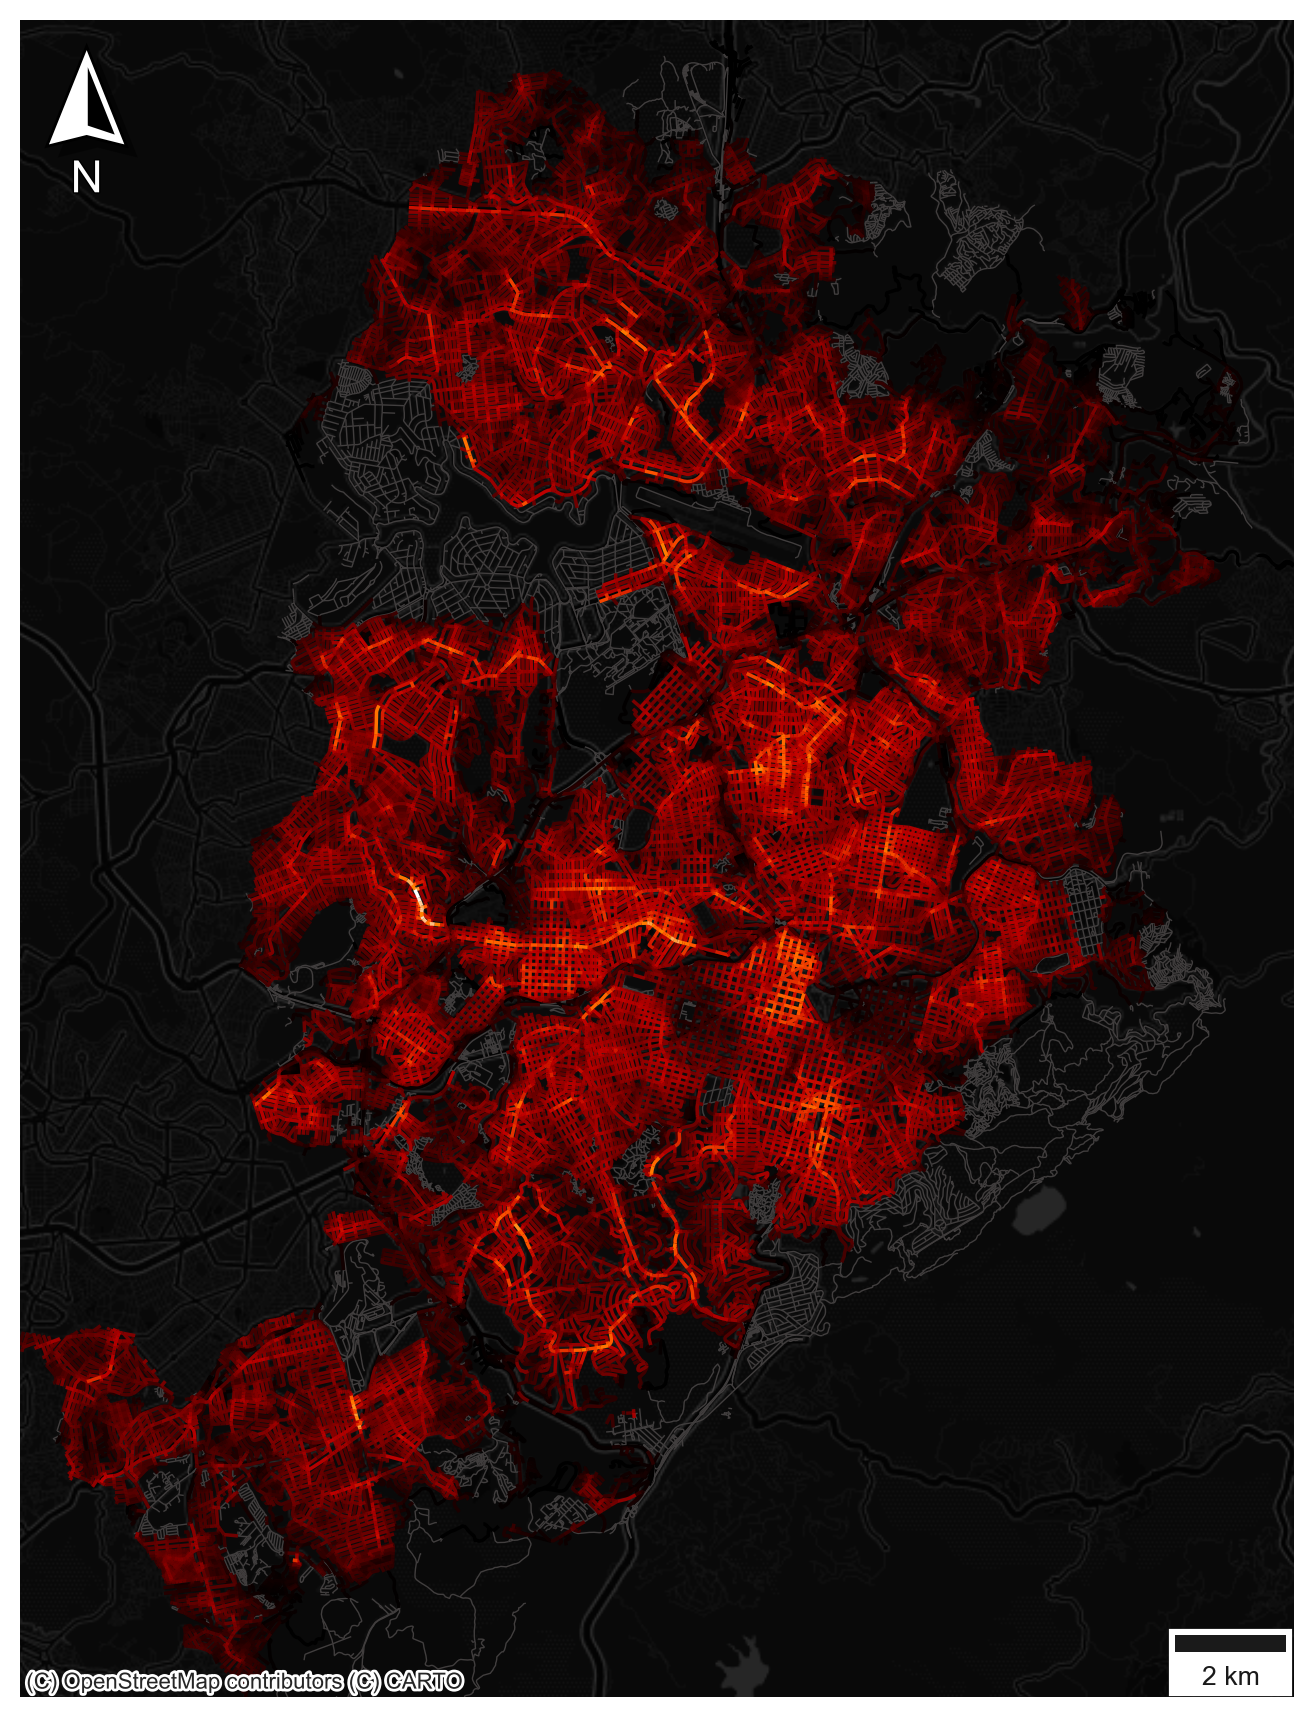

In [23]:
metric = "hill_q2"
fig, ax = simple_map(
    db,
    column=metric,
    cmap="gist_heat",
    #scheme="NaturalBreaks",
    #k=3,
    #scalebar_loc="lower right",
)


In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as cx
from matplotlib_map_utils.core.north_arrow import north_arrow


def simple_map_grid(
    gdf: gpd.GeoDataFrame,
    columns: list[str],                 # 4 variables, continuous
    titles: list[str] | None = None,    # optional per-panel titles
    cmap: str = "managua",
    scheme: str | None = None,          # keep for future (e.g., "quantiles"); None => continuous
    k: int | None = None,
    a4_width_in: float = 8.27,
    linewidth: float = .85,
    north_kwargs: dict | None = None,   # forwarded to your north_arrow
    scalebar_loc: str = "lower right",
    basemap = cx.providers.CartoDB.DarkMatterNoLabels,
    base_nodes: gpd.GeoDataFrame | None = nodes,  # optional "context" layer to show beneath
    left: float = 0.06,
    right: float = 0.985,
    bottom: float = 0.05,
    top: float = 0.98,
    wspace: float = 0.02,
    hspace: float = 0.02,
):
    """
    Plot a 2x2 grid of thematic maps (continuous by default), each with:
      - legend outside (left of each subplot),
      - north arrow (upper-left),
      - scale bar (lower-right),
      - Contextily basemap,
      - A4 width; figure height preserves bbox aspect per panel times 2 rows.
    """
    assert len(columns) == 4, "Provide exactly four columns for a 2x2 grid."

    # Project to Web Mercator for basemap + metric scalebar
    g = gdf.to_crs(3857)
    n = None
    if base_nodes is not None:
        n = base_nodes.to_crs(3857)
        # leave only features not in g (like your “unused links” idea)
        if hasattr(n, "index") and hasattr(g, "index"):
            n = n.loc[~n.index.isin(g.index)]

    # --- aspecto do dado (altura/largura do bbox) ----------------------------
    xmin, ymin, xmax, ymax = g.total_bounds
    w_data = max(xmax - xmin, 1e-9)
    h_data = max(ymax - ymin, 1e-9)
    aspect = h_data / w_data  # altura/largura por painel

    # --- calcula a ALTURA exata da figura p/ 2×2 dado o GridSpec -------------
    # fração de largura útil para eixos
    avail_w = right - left
    ax_w_frac = avail_w / (2 + (2 - 1) * wspace)
    # altura de cada eixo em fração da largura da figura (pois aspect = h/w)
    ax_h_frac_of_figwidth = ax_w_frac * aspect
    # altura total ocupada pelos eixos (duas linhas + hspace)
    total_h_frac_of_figwidth = ax_h_frac_of_figwidth * (2 + (2 - 1) * hspace)
    # converte para altura da figura em polegadas, corrigindo top/bottom
    fig_h_in = a4_width_in * total_h_frac_of_figwidth / (top - bottom)
    
    # --- cria figura/subplots já com espaçamentos controlados ----------------
    fig, axes = plt.subplots(
        2, 2, figsize=(a4_width_in, fig_h_in), facecolor="white"
    )
    fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top,
                        wspace=wspace, hspace=hspace)
    axes = axes.ravel()

    # North arrow defaults
    na_opts = dict(
        location="upper left",
        rotation={"crs": g.crs, "reference": "center"},
        label={
            'stroke_color': 'black',
            'color': 'white',
        }
        )
    if north_kwargs:
        na_opts.update(north_kwargs)

    # Plot each panel
    for ax, col_idx in zip(axes, range(4)):
        col = columns[col_idx]

        # Optional context layer beneath
        if n is not None:
            n.plot(ax=ax, color="#444040", linewidth=0.5)

        # Choropleth (continuous if scheme is None)
        g.sort_values(col).plot(
            column=col,
            cmap=cmap,
            linewidth=linewidth,
            ax=ax,
            legend=False,
        )

        # Basemap
        cx.add_basemap(
            ax=ax, crs=g.crs, source=basemap,
            attribution_size=6,
            )

        # North arrow & scale bar
        north_arrow(ax, **na_opts)
        ax.add_artist(ScaleBar(1.0, units="m", location=scalebar_loc, frameon=True))

        # Extent & cosmetics
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.axis("off")

        # Optional per-panel title
        if titles and col_idx < len(titles) and titles[col_idx]:
            ax.set_title(titles[col_idx], fontsize=10, pad=4)

    plt.tight_layout()
    plt.show()
    return fig, axes


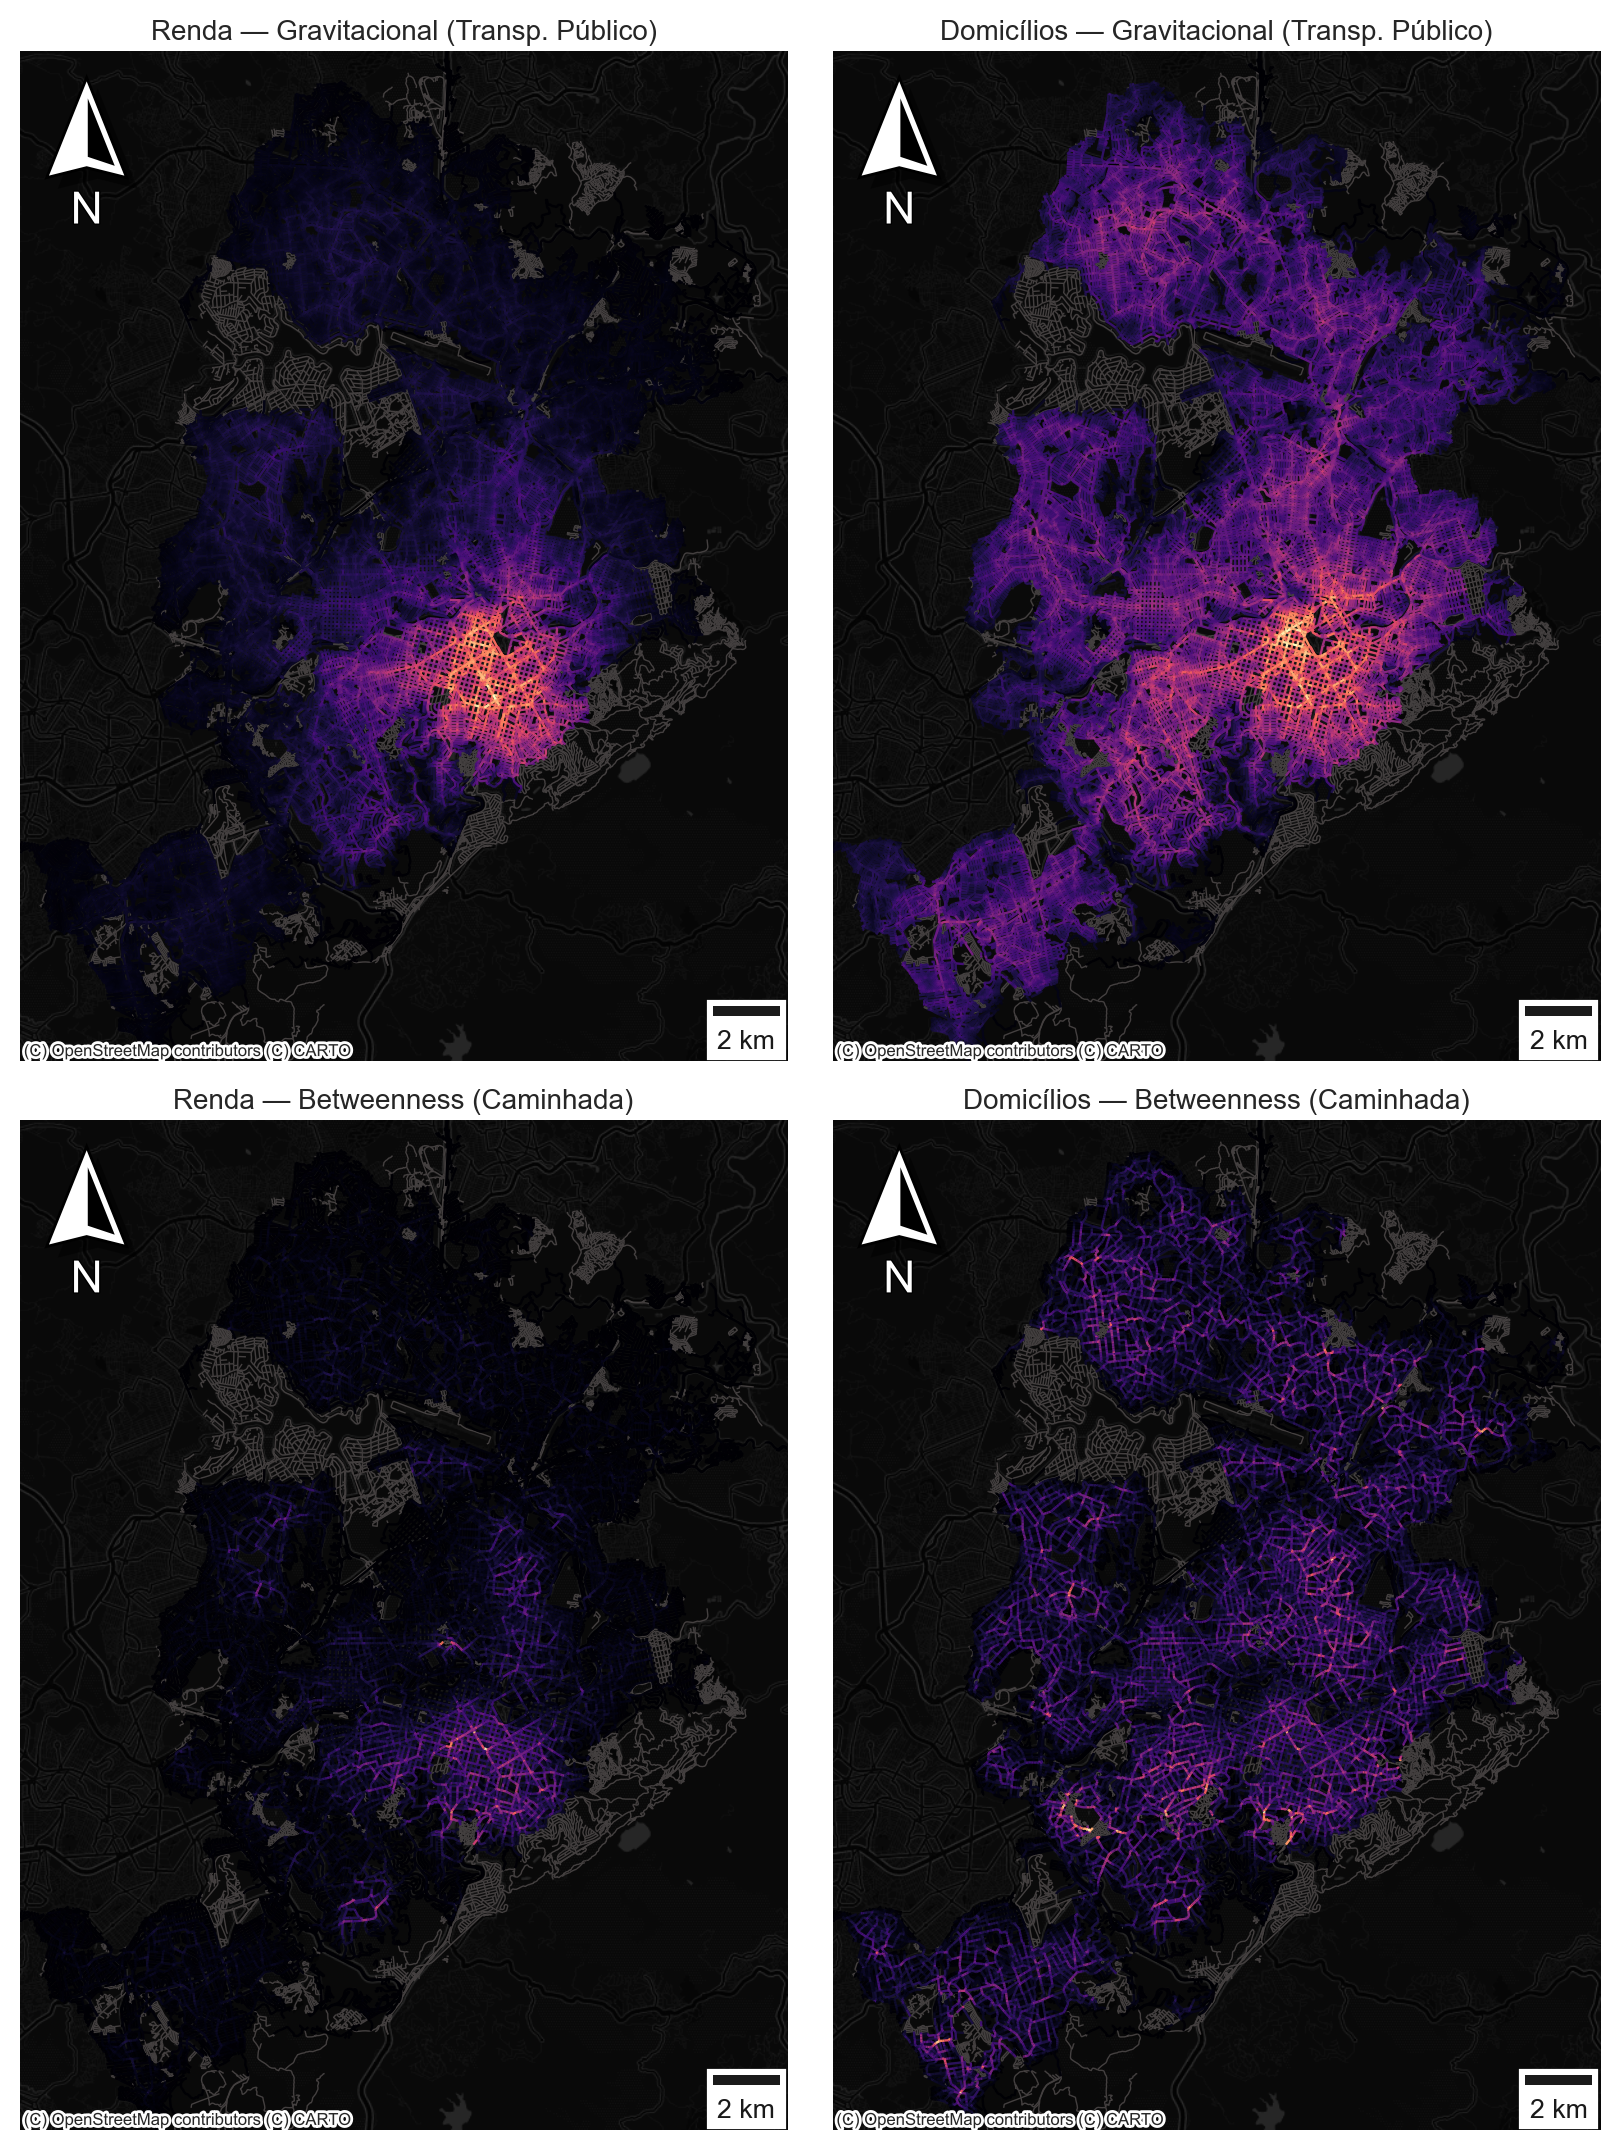

In [18]:
cols = [
    "income_beta_public",
    "households_beta_public",
    "income_betweenness_beta_walk",
    "households_betweenness_beta_walk"]
fig, axes = simple_map_grid(
    gdf=db,
    columns=cols,
    titles=[
        "Renda — Gravitacional (Transp. Público)",
        "Domicílios — Gravitacional (Transp. Público)",
        "Renda — Betweenness (Caminhada)",
        "Domicílios — Betweenness (Caminhada)",
        ],
    cmap="magma",
)


In [185]:
cx.add_basemap?

Signature:
cx.add_basemap(
    ax,
    zoom='auto',
    source=None,
    interpolation='bilinear',
    attribution=None,
    attribution_size=8,
    reset_extent=True,
    crs=None,
    resampling=<Resampling.bilinear: 1>,
    zoom_adjust=None,
    **extra_imshow_args,
)
Docstring:
Add a (web/local) basemap to `ax`.

Parameters
----------
ax : AxesSubplot
    Matplotlib axes object on which to add the basemap. The extent of the
    axes is assumed to be in Spherical Mercator (EPSG:3857), unless the `crs`
    keyword is specified.
zoom : int or 'auto'
    [Optional. Default='auto'] Level of detail for the basemap. If 'auto',
    it is calculated automatically. Ignored if `source` is a local file.
source : xyzservices.TileProvider object or str
    [Optional. Default: OpenStreetMap Humanitarian web tiles]
    The tile source: web tile provider, a valid input for a query of a
    :class:`xyzservices.TileProvider` by a name from ``xyzservices.providers`` or
    path to local file. The web 

In [173]:
db.columns

Index(['x', 'y', 'primal_edge', 'accessibility', 'hill_q0', 'hill_q1',
       'hill_q2', 'income_betweenness_beta_public', 'income_harmonic_public',
       'income_beta_public', 'income_betweenness_beta_private',
       'income_harmonic_private', 'income_beta_private',
       'income_betweenness_beta_walk', 'income_harmonic_walk',
       'income_beta_walk', 'households_betweenness_beta_public',
       'households_harmonic_public', 'households_beta_public',
       'households_betweenness_beta_private', 'households_harmonic_private',
       'households_beta_private', 'households_betweenness_beta_walk',
       'households_harmonic_walk', 'households_beta_walk', 'bueiros',
       'obstaculo_calcada', 'rampa_cadeirante', 'com_arvores', 'crime_rate',
       'slope'],
      dtype='object')

In [174]:
db = db.fillna(0)

# Variable Preparation

In [175]:
def fit_zscores(df: pd.DataFrame, cols: Sequence[str]):
    """
    Fit a z-score transformer on `cols` of df and return:
      - Z: DataFrame with z-scored columns (same index/columns)
      - scaler: fitted StandardScaler (has mean_ and scale_)
      - meta: tidy table with mean and std for documentation
    """
    X = df.loc[:, cols].astype(float)
    scaler = StandardScaler(with_mean=True, with_std=True)
    Z = pd.DataFrame(scaler.fit_transform(X), columns=cols, index=df.index)

    meta = pd.DataFrame(
        {"mean": scaler.mean_, "std": scaler.scale_}, index=cols
    )
    return Z, scaler, meta

def apply_zscores(df: pd.DataFrame, cols: Sequence[str],
                  scaler: StandardScaler) -> pd.DataFrame:
    """Apply a fitted scaler to new data with the same columns."""
    X = df.loc[:, cols].astype(float)
    Z = pd.DataFrame(scaler.transform(X), columns=cols, index=df.index)
    return Z

def invert_zscores(Z: pd.DataFrame, scaler: StandardScaler) -> pd.DataFrame:
    """Return variables to their original units."""
    X = pd.DataFrame(
        scaler.inverse_transform(Z.values),
        columns=Z.columns, index=Z.index
    )
    return X


In [176]:
# Transform target variable
# Log-transform to reduce skewness
y_name = 'accessibility'
y, y_scaler, y_meta = fit_zscores(
    db.assign(accessibility=np.log1p(db[y_name])),
    [y_name]
    )

# Persist the transformer for later reuse/reversal
joblib.dump(y_scaler, "model_data/y_zscore_scaler.joblib")
y_meta.to_csv("model_data/y_zscore_params.csv", index=True)  # human-readable record)

# Fit scaler on predictors
x_names = db.iloc[:, 4:].columns.tolist()
X, x_scaler, x_meta = fit_zscores(db, x_names)

# Again, persist the transformer         
joblib.dump(x_scaler, "model_data/X_zscore_scaler.joblib")
x_meta.to_csv("model_data/X_zscore_params.csv", index=True)  # human-readable record)

# Regression and Diagnostics

In [177]:
X = X.drop(columns=X.filter(like='harmonic').columns)
#X = X.drop(columns=X.filter(like='walk').columns)
X = X.drop(columns=X.filter(like='private').columns)
X = X.drop(columns=[
    'hill_q0', 'hill_q2',
    'households_betweenness_beta_public',
    'income_betweenness_beta_public',
    'households_beta_walk',
    'income_beta_walk',
    ])

X_names = X.columns.tolist()

In [178]:
df = pd.concat([y, X], axis=1)
df['has_retail'] = np.where(
    df.accessibility > 0, 1, 0
)
df.head()

,accessibility,hill_q1,income_beta_public,income_betweenness_beta_walk,households_beta_public,households_betweenness_beta_walk,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores,crime_rate,slope,has_retail
257609528_5000025481_k0,-0.96,-0.28,-0.58,-0.61,-0.16,-0.77,-1.86,-2.18,-0.97,-2.87,-0.32,-0.85,0
257609528_316683844_k0,-0.61,-0.74,-0.54,-0.32,0.10,0.43,-1.86,-2.18,-0.97,-2.87,-0.32,-1.07,0
257609528_316683843_k0,-0.91,-0.00,-0.58,-0.34,-0.14,0.40,-1.86,-2.18,-0.97,-2.87,-0.32,-0.88,0
316683843_316761921_k0,-1.31,-0.75,-0.67,-0.58,-0.60,-0.60,-0.84,0.52,-0.97,-1.22,-0.32,-0.66,0
316683843_316761938_k0,-0.90,0.73,-0.61,-0.32,-0.30,0.53,-0.84,0.52,-0.97,-1.22,-0.32,-0.84,0


## Exploring

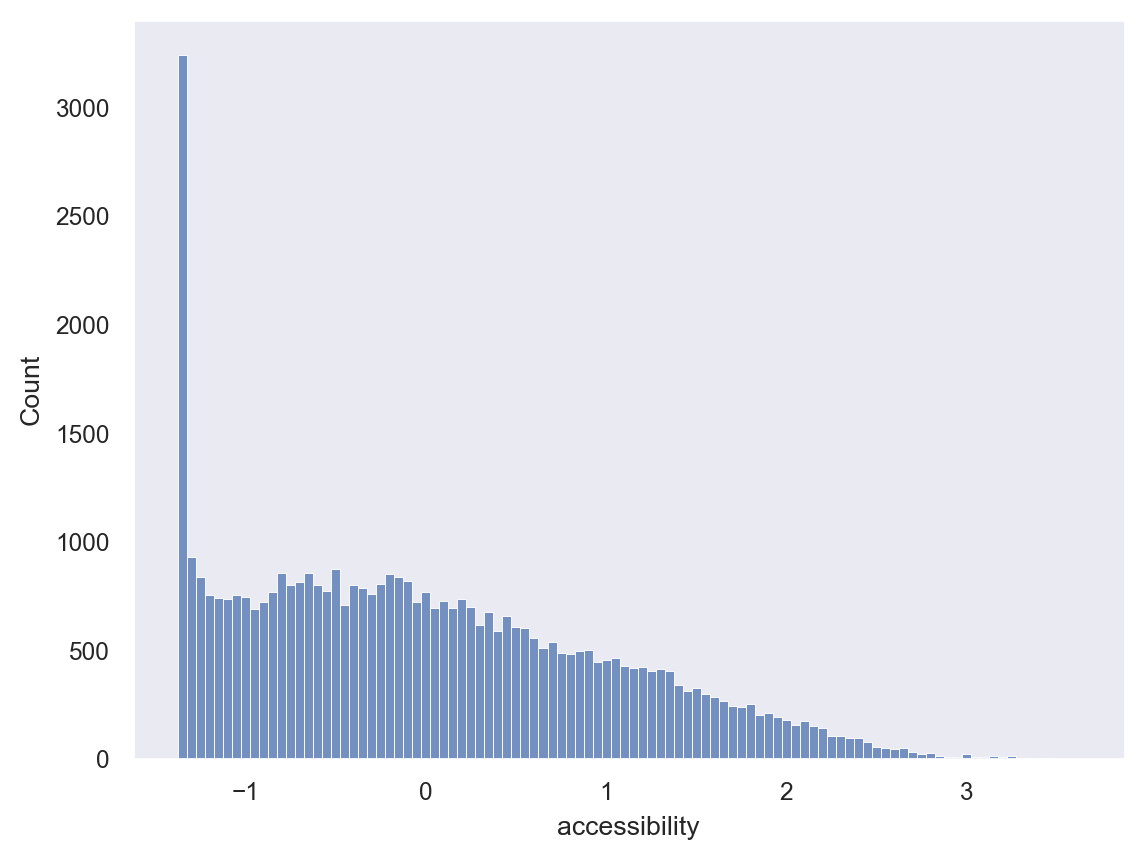

In [179]:
sns.histplot(
    y['accessibility'],
    bins=100,
)

plt.show()

In [180]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
accessibility,"44,140.00",0.00,1.00,-1.38,-0.82,-0.14,0.69,3.63
hill_q1,"44,140.00",0.00,1.00,-2.90,-0.62,0.06,0.70,3.41
income_beta_public,"44,140.00",0.00,1.00,-0.90,-0.58,-0.35,0.11,6.45
income_betweenness_beta_walk,"44,140.00",-0.00,1.00,-0.67,-0.55,-0.32,0.11,16.27
households_beta_public,"44,140.00",-0.00,1.00,-1.95,-0.66,-0.17,0.48,5.76
households_betweenness_beta_walk,"44,140.00",-0.00,1.00,-1.05,-0.76,-0.26,0.47,8.27
bueiros,"44,140.00",-0.00,1.00,-1.86,-0.75,0.05,0.82,1.52
obstaculo_calcada,"44,140.00",-0.00,1.00,-2.18,-0.65,0.25,0.82,1.19
rampa_cadeirante,"44,140.00",0.00,1.00,-0.97,-0.91,-0.31,0.62,2.34
com_arvores,"44,140.00",0.00,1.00,-2.87,-0.62,0.17,0.80,1.26


In [181]:
df.corr(method='spearman')

,accessibility,hill_q1,income_beta_public,income_betweenness_beta_walk,households_beta_public,households_betweenness_beta_walk,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores,crime_rate,slope,has_retail
accessibility,1.00,0.50,0.74,0.57,0.56,0.30,0.18,-0.15,0.51,0.44,0.40,-0.11,0.86
hill_q1,0.50,1.00,0.51,0.41,0.48,0.32,0.05,0.03,0.31,0.15,0.15,-0.21,0.42
income_beta_public,0.74,0.51,1.00,0.60,0.85,0.34,0.25,-0.15,0.52,0.36,0.37,-0.15,0.63
income_betweenness_beta_walk,0.57,0.41,0.60,1.00,0.57,0.89,0.13,-0.07,0.32,0.25,0.19,-0.10,0.47
households_beta_public,0.56,0.48,0.85,0.57,1.00,0.45,0.18,-0.10,0.40,0.21,0.23,-0.19,0.45
households_betweenness_beta_walk,0.30,0.32,0.34,0.89,0.45,1.00,0.03,0.04,0.11,0.04,0.00,-0.05,0.22
bueiros,0.18,0.05,0.25,0.13,0.18,0.03,1.00,-0.06,0.26,0.23,0.24,-0.09,0.13
obstaculo_calcada,-0.15,0.03,-0.15,-0.07,-0.10,0.04,-0.06,1.00,-0.29,-0.05,-0.17,0.15,-0.14
rampa_cadeirante,0.51,0.31,0.52,0.32,0.40,0.11,0.26,-0.29,1.00,0.48,0.42,-0.26,0.44
com_arvores,0.44,0.15,0.36,0.25,0.21,0.04,0.23,-0.05,0.48,1.00,0.34,-0.06,0.36


C:\Users\brand\AppData\Local\Temp\ipykernel_15172\1394363231.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


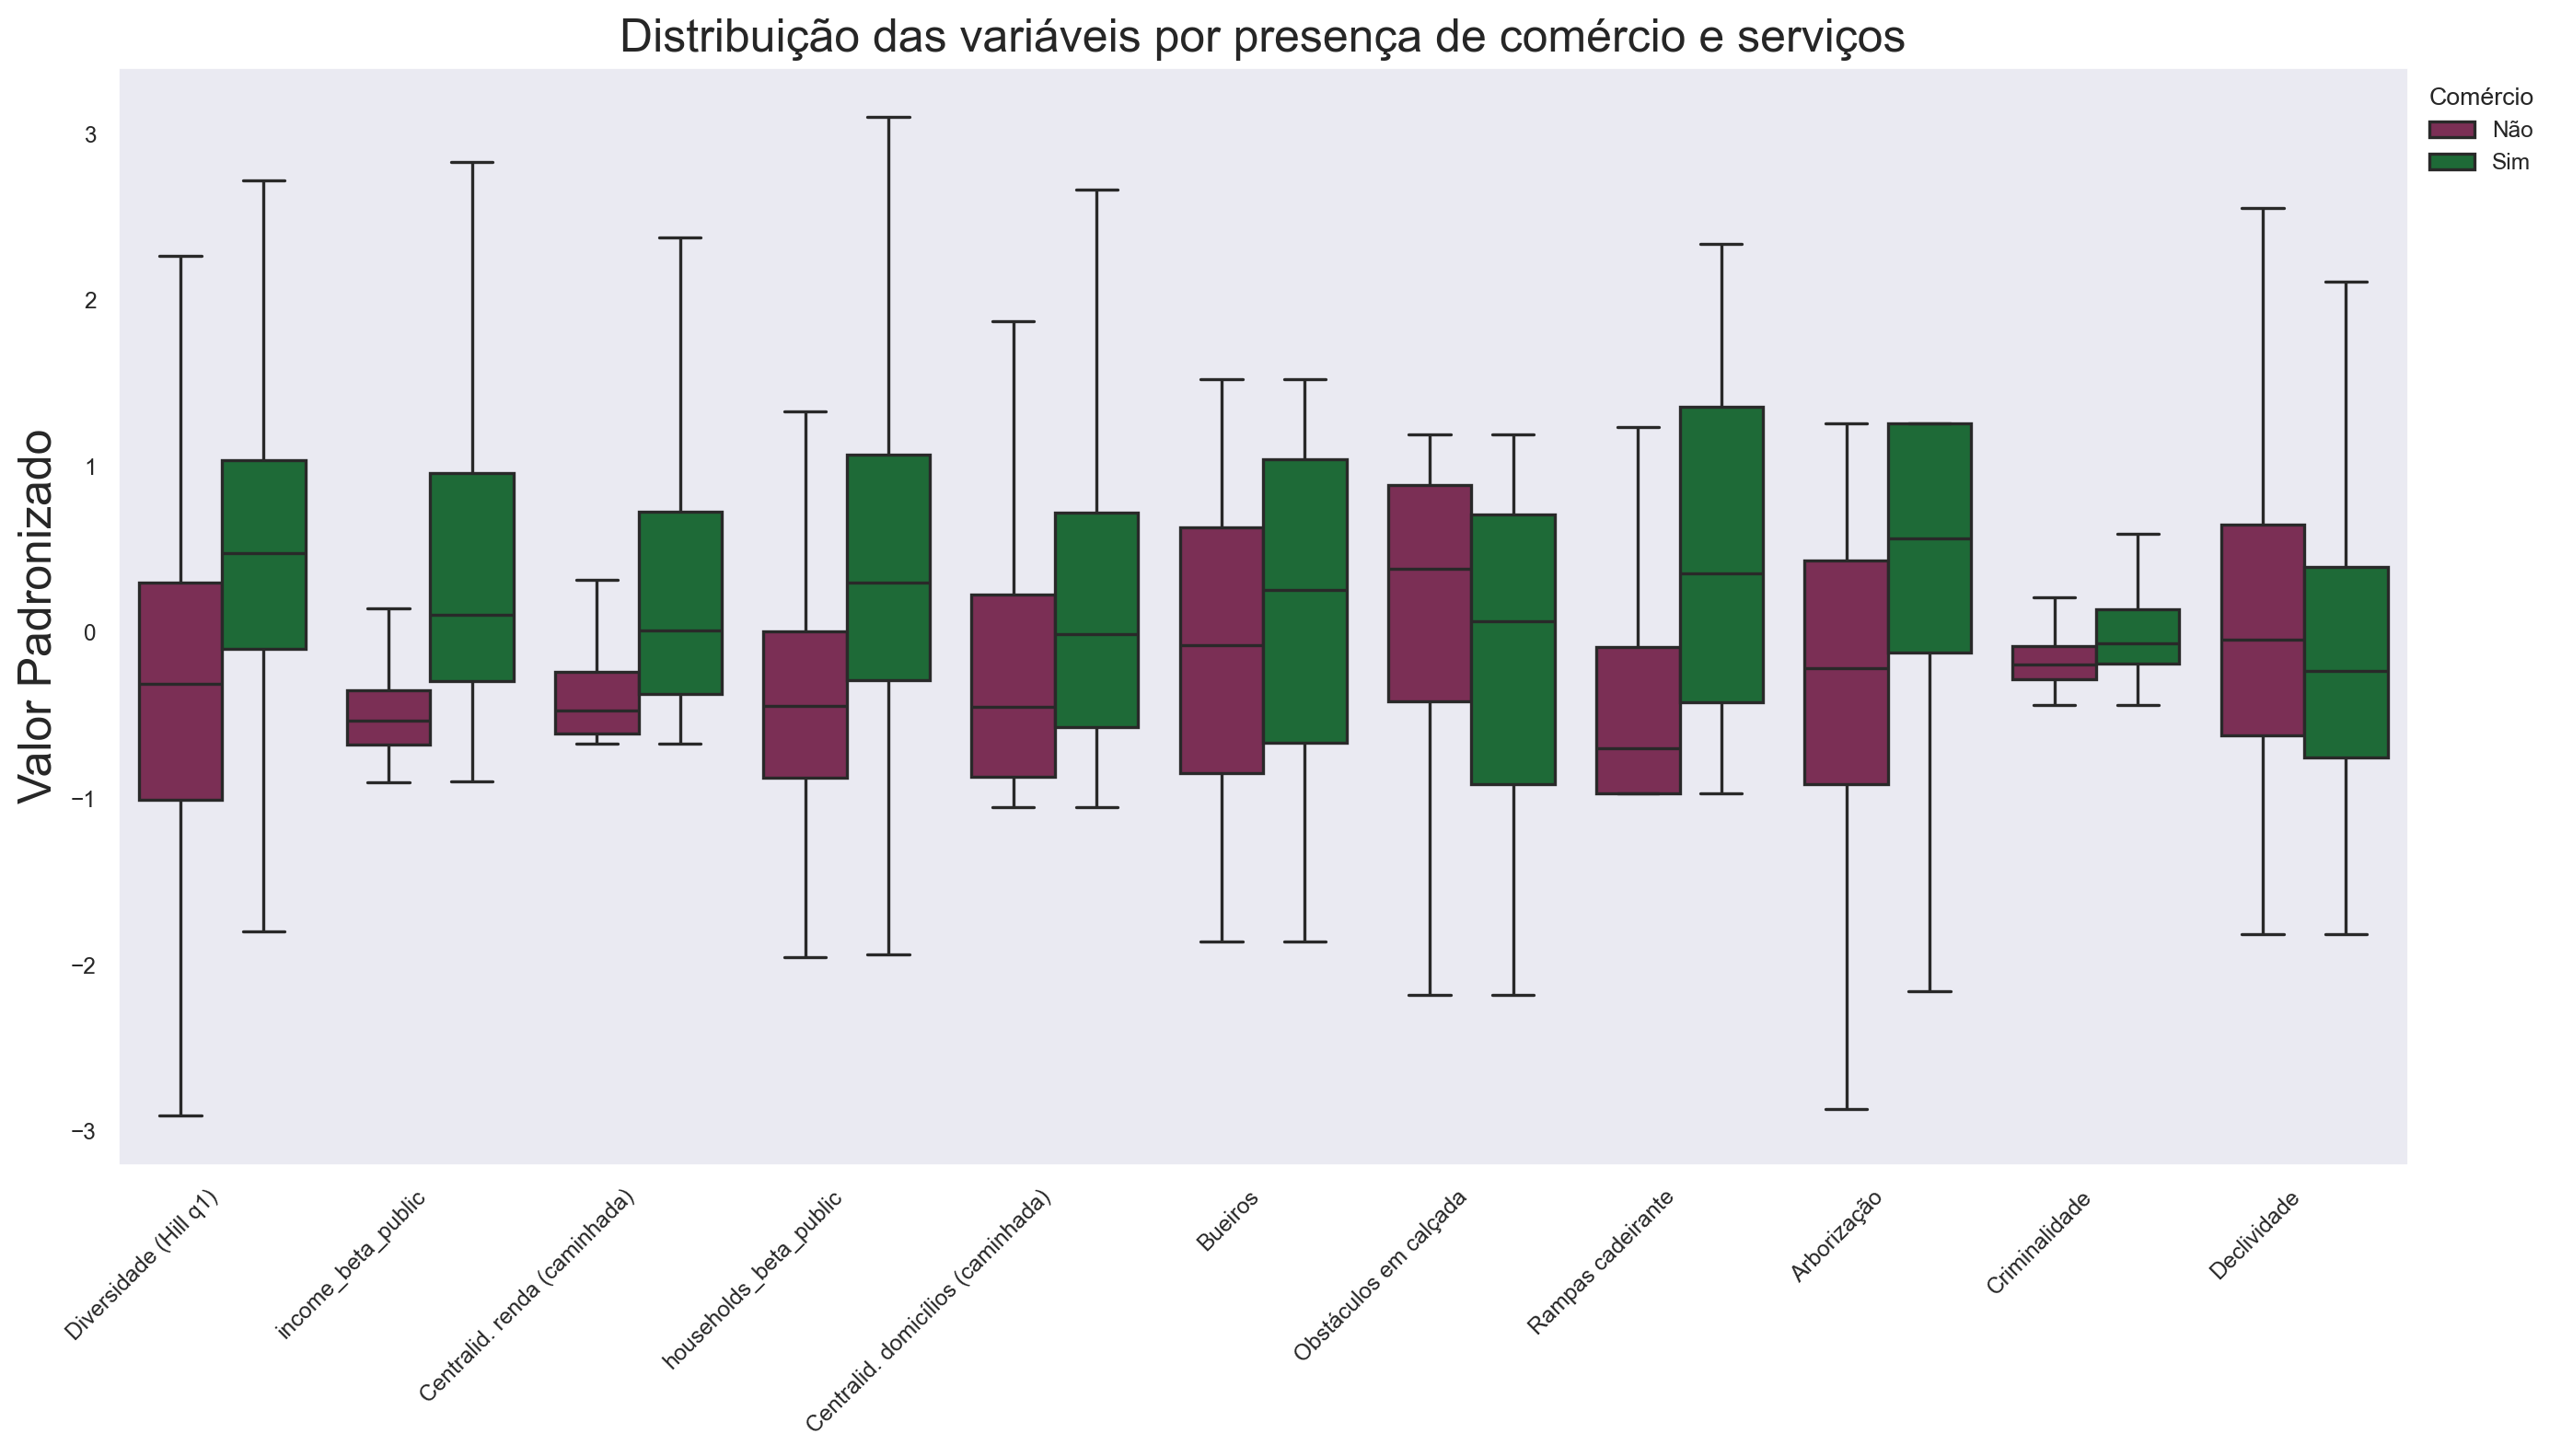

In [182]:
df_long = df.drop(columns=['accessibility']).melt(
    id_vars="has_retail",
    var_name="variable",
    value_name="value"
).replace({"has_retail": {0: "Não", 1: "Sim"}})

rename_dict = {
    "hill_q1": "Diversidade (Hill q1)",
    "income_harmonic_public": "Acess. renda (TP)",
    "income_betweenness_beta_walk": "Centralid. renda (caminhada)",
    "households_harmonic_public": "Acess. domicílios (TP)",
    "households_betweenness_beta_walk": "Centralid. domicílios (caminhada)",
    "bueiros": "Bueiros",
    "obstaculo_calcada": "Obstáculos em calçada",
    "rampa_cadeirante": "Rampas cadeirante",
    "com_arvores": "Arborização",
    "crime_rate": "Criminalidade",
    "slope": "Declividade"
}
df_long = df_long.replace({'variable': rename_dict})

# --- Plot ---
plt.figure(figsize=(14, 8))

palette = {
    'Não': "#882255",   # azul — sem comércio
    'Sim': "#117733"    # laranja — com comércio
}

ax = sns.boxplot(
    data=df_long,
    x="variable",
    y="value",
    hue="has_retail",
    showfliers=False,
    linewidth=1.2,
    palette=palette,
)

# --- Eixo x mais limpo ---
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Valor Padronizado", fontsize=18)

# --- Título e legendas ---
ax.legend(
    title="Comércio",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False
)
plt.title("Distribuição das variáveis por presença de comércio e serviços", fontsize=18)

# --- Margens e layout ---
plt.tight_layout()
plt.show()


In [183]:
model = OLS(y, add_constant(X))
ols = model.fit()

In [184]:
style_talk = 'seaborn-talk'    #refer to plt.style.available

class LinearRegDiagnostic():
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Authors:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.

        Matt Spinelli (m3spinelli@gmail.com, where 3 = r)
        (1) Fixed incorrect annotation of the top most extreme residuals in
            the Residuals vs Fitted and, especially, the Normal Q-Q plots.
        (2) Changed Residuals vs Leverage plot to match closer the y-axis
            range shown in the equivalent plot in the R package ggfortify.
        (3) Added horizontal line at y=0 in Residuals vs Leverage plot to
            match the plots in R package ggfortify and base R.
        (4) Added option for placing a vertical guideline on the Residuals
            vs Leverage plot using the rule of thumb of h = 2p/n to denote
            high leverage (high_leverage_threshold=True).
        (5) Added two more ways to compute the Cook's Distance (D) threshold:
            * 'baseR': D > 1 and D > 0.5 (default)
            * 'convention': D > 4/n
            * 'dof': D > 4 / (n - k - 1)
        (6) Fixed class name to conform to Pascal casing convention
        (7) Fixed Residuals vs Leverage legend to work with loc='best'
    """

    def __init__(self,
                 results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-v0_8-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
            raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)
        self.nresids = len(self.residual_norm)

    def __call__(self, plot_context='seaborn-v0_8-paper', **kwargs):
        # print(plt.style.available)
        # GH#9157
        if plot_context not in plt.style.available:
            plot_context = 'default'
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
            self.residual_plot(ax=ax[0,0])
            self.qq_plot(ax=ax[0,1])
            self.scale_location_plot(ax=ax[1,0])
            self.leverage_plot(
                ax=ax[1,1],
                high_leverage_threshold = kwargs.get('high_leverage_threshold'),
                cooks_threshold = kwargs.get('cooks_threshold'))
            plt.show()

        return self.vif_table(), fig, ax,

    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.argsort(residual_abs), 0)
        abs_resid_top_3 = abs_resid[:3]
        for i in abs_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], self.residual[i]),
                color='C3')

        ax.set_title('Residuals vs Fitted', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Residuals')
        return ax

    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        fig = QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for i, x, y in self.__qq_top_resid(QQ.theoretical_quantiles, abs_norm_resid_top_3):
            ax.annotate(
                i,
                xy=(x, y),
                ha='right',
                color='C3')

        ax.set_title('Normal Q-Q', fontweight="bold")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Standardized Residuals')
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False, ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], residual_norm_abs_sqrt[i]),
                color='C3')

        ax.set_title('Scale-Location', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
        return ax

    def leverage_plot(self, ax=None, high_leverage_threshold=False, cooks_threshold='baseR'):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(
            self.leverage,
            self.residual_norm,
            alpha=0.5);

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(
                i,
                xy=(self.leverage[i], self.residual_norm[i]),
                color = 'C3')

        factors = []
        if cooks_threshold == 'baseR' or cooks_threshold is None:
            factors = [1, 0.5]
        elif cooks_threshold == 'convention':
            factors = [4/self.nresids]
        elif cooks_threshold == 'dof':
            factors = [4/ (self.nresids - self.nparams)]
        else:
            raise ValueError("threshold_method must be one of the following: 'convention', 'dof', or 'baseR' (default)")
        for i, factor in enumerate(factors):
            label = "Cook's distance" if i == 0 else None
            xtemp, ytemp = self.__cooks_dist_line(factor)
            ax.plot(xtemp, ytemp, label=label, lw=1.25, ls='--', color='red')
            ax.plot(xtemp, np.negative(ytemp), lw=1.25, ls='--', color='red')

        if high_leverage_threshold:
            high_leverage = 2 * self.nparams / self.nresids
            if max(self.leverage) > high_leverage:
                ax.axvline(high_leverage, label='High leverage', ls='-.', color='purple', lw=1)

        ax.axhline(0, ls='dotted', color='black', lw=1.25)
        ax.set_xlim(0, max(self.leverage)+0.01)
        ax.set_ylim(min(self.residual_norm)-0.1, max(self.residual_norm)+0.1)
        ax.set_title('Residuals vs Leverage', fontweight="bold")
        ax.set_xlabel('Leverage')
        ax.set_ylabel('Standardized Residuals')
        plt.legend(loc='best')
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]

        return (vif_df
                .sort_values("VIF Factor")
                .round(2))


    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y


    def __qq_top_resid(self, quantiles, top_residual_indices):
        """
        Helper generator function yielding the index and coordinates
        """
        offset = 0
        quant_index = 0
        previous_is_negative = None
        for resid_index in top_residual_indices:
            y = self.residual_norm[resid_index]
            is_negative = y < 0
            if previous_is_negative == None or previous_is_negative == is_negative:
                offset += 1
            else:
                quant_index -= offset
            x = quantiles[quant_index] if is_negative else np.flip(quantiles, 0)[quant_index]
            quant_index += 1
            previous_is_negative = is_negative
            yield resid_index, x, y


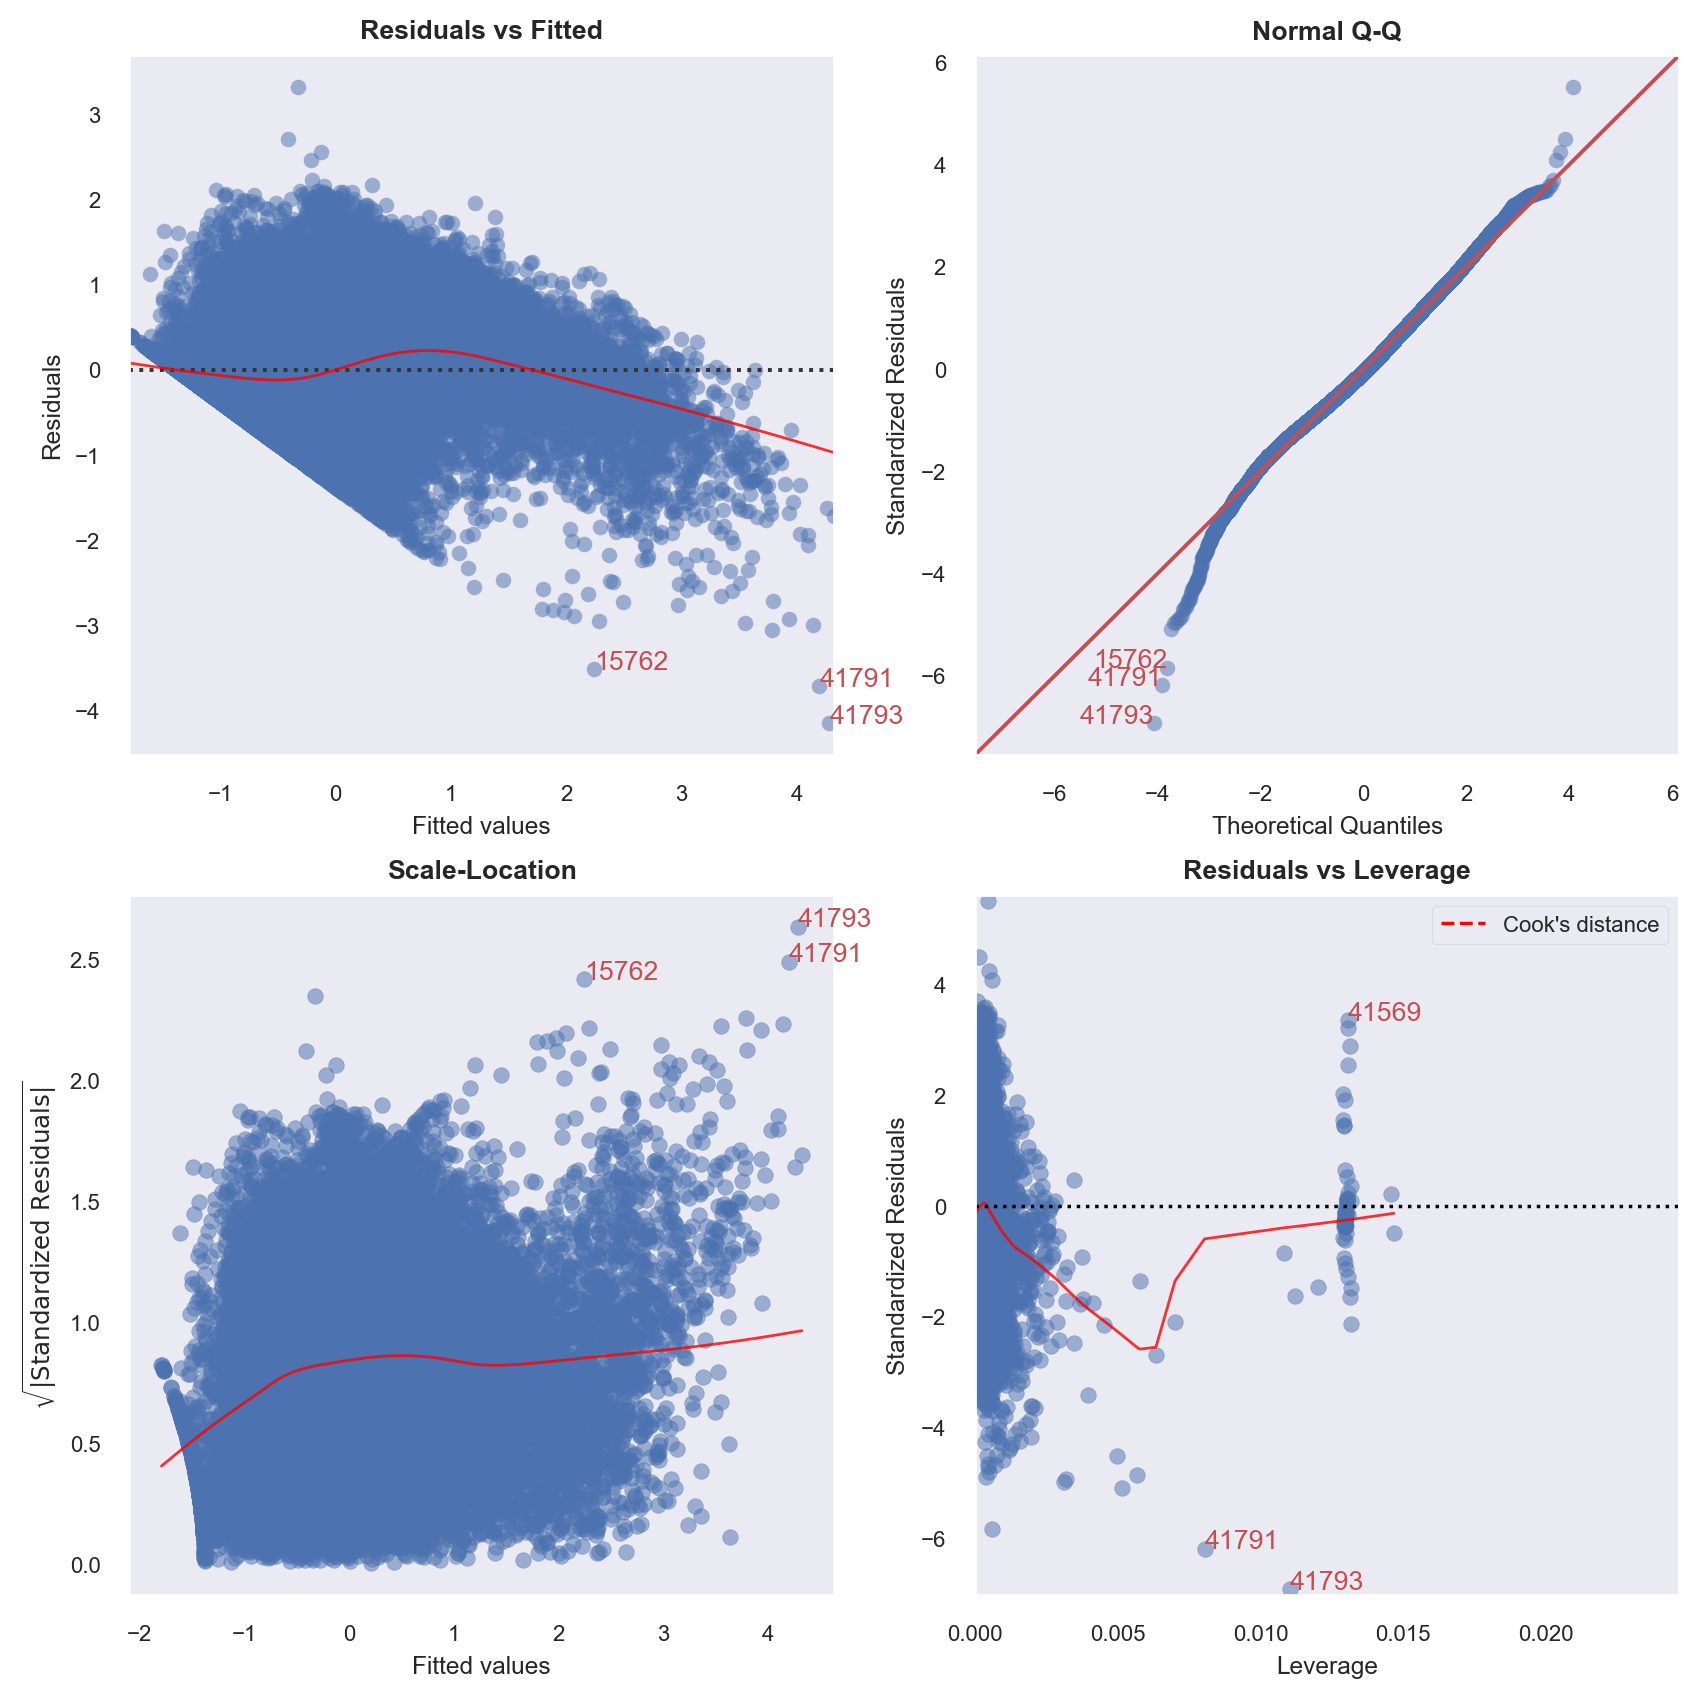

In [185]:
# Alternatively, all diagnostics can be generated in one go as follows.
# Fig and ax can be used to modify axes or plot properties after the fact.
cls = LinearRegDiagnostic(ols)
vif, fig, ax = cls()

In [186]:
vif

,Features,VIF Factor
0,const,1.00
10,crime_rate,1.08
11,slope,1.14
6,bueiros,1.16
7,obstaculo_calcada,1.32
9,com_arvores,1.42
1,hill_q1,1.43
8,rampa_cadeirante,1.99
5,households_betweenness_beta_walk,3.15
3,income_betweenness_beta_walk,4.43


In [187]:
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          accessibility   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     7057.
Date:                Tue, 14 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:14:01   Log-Likelihood:                -40233.
No. Observations:               44140   AIC:                         8.049e+04
Df Residuals:                   44128   BIC:                         8.059e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                             8.327e-17      0.003   2.91e-14      1.000      -0.006       0.006
hill_q1                              0.3133      0.003     91.441      0.000       0.307       0.320
income_beta_public                   0.6230      0.008     74.614      0.000       0.607       0.639
income_betweenness_beta_walk         0.1056      0.006     17.510      0.000       0.094       0.117
households_beta_public              -0.2002      0.007    -28.099      0.000      -0.214      -0.186
households_betweenness_beta_walk     0.0076      0.005      1.490      0.136      -0.002       0.018
bueiros                             -0.0452      0.003    -14.675      0.000      -0.051      -0.039
obstaculo_calcada                    0.0033      0.003      0.994      0.320      -0.003       0.010
rampa_cadeirante                     0.1265      0.004     31.323      0.000       0.119       0.134
com_arvores                          0.1412      0.003     41.313      0.000       0.135       0.148
crime_rate                          -0.0160      0.003     -5.394      0.000      -0.022      -0.010
slope                                0.0465      0.003     15.172      0.000       0.040       0.052
==============================================================================
Omnibus:                      415.135   Durbin-Watson:                   0.783
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              594.784
Skew:                           0.114   Prob(JB):                    6.99e-130
Kurtosis:                       3.521   Cond. No.                         7.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""